In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sympy.physics.quantum.dagger import Dagger
import math
import random
import cmath
from sympy import I, Matrix, symbols
from sympy.physics.quantum import TensorProduct
import pandas as pd
from IPython.display import clear_output
import Hamiltonian
import build_H
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cpu'
number_of_qubits = 12
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)


sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch




tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])
6
torch.Size([924]) torch.Size([924])


torch.Size([1024])


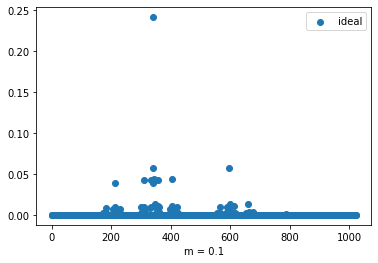

In [5]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_10.npy')).float()

my_way = torch.zeros(2**10, dtype = torch.double)
print(eigenvectors.shape)
x = torch.arange(2**10)
my_way = eigenvectors
fig, ax = plt.subplots()
ax.scatter(x, eigenvectors**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

In [6]:
def CP_conj(batch):
    add = torch.clone(batch)
    CP_batch = torch.clone(batch)
    i = torch.arange(0,number_of_qubits/2,1).type(torch.LongTensor)
    j = torch.arange(number_of_qubits-1, number_of_qubits/2-1, -1).type(torch.LongTensor)
    CP_batch[:,i] = CP_batch[:,j]
    CP_batch[:,j] = add[:,i]
    add = torch.clone(CP_batch)

    CP_batch[add == 0] = 1
    CP_batch[add == 1] = 0
    return CP_batch

In [7]:
print(number_of_qubits)

12


tensor(0.8481) tensor(0.9470)


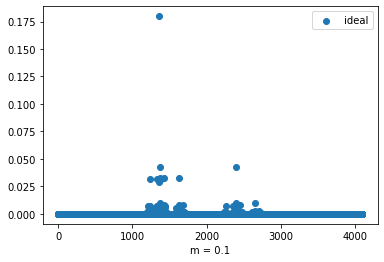

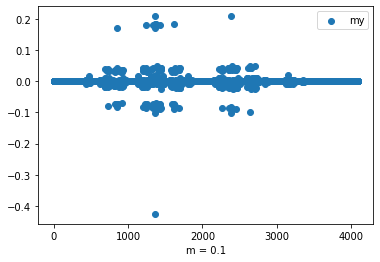

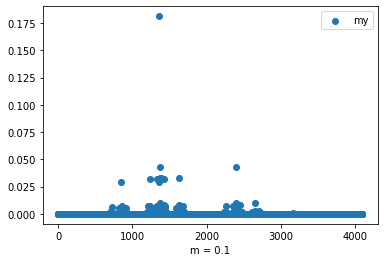

In [8]:
R = my_way.reshape(-1)

# distr = torch.zeros(2**number_of_qubits)
# ind = torch.arange(2**(number_of_qubits - 2))
# distr[ind + 2**(number_of_qubits - 2)] = R[ind]*0.87
# distr[ind + 2**(number_of_qubits - 1)] = -R[ind]*0.44

R = my_way.reshape(-1)
#RR= my_way_8.reshape(-1)
distr = torch.zeros(2**number_of_qubits)
ind = torch.arange(2**(number_of_qubits - 2))
#ind1 = torch.arange(2**(number_of_qubits - 3))
ind2 = torch.arange(2**(number_of_qubits - 4))
distr[ind2 + 2**(number_of_qubits - 2)] = R[ind2]*0.896

distr[ind2 + 2**(number_of_qubits - 2) + 2**(number_of_qubits - 4)] = R[ind2 +  2**(number_of_qubits - 4)]*0.863

distr[ind2 + 2**(number_of_qubits - 2) + 2**(number_of_qubits - 3)] = R[ind2 +  2**(number_of_qubits - 3)]*0.757

distr[ind + 2**(number_of_qubits - 1)] = -R[ind]*0.4213
r = distr[1024:2048]
print(r.norm(), distr.norm())

fig, ax = plt.subplots()
x = torch.arange(2**number_of_qubits)
ax.scatter(x, distr**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

ind = (torch.abs(distr) > 0.001).nonzero()
batch = basis[ind].view(-1, number_of_qubits)

CP_batch = CP_conj(batch)
#number_of_qubits = 16
a = 2**torch.arange(number_of_qubits -1, -1,-1)
CP_ind = CP_batch*a 
CP_ind = (CP_ind.sum(dim = 1)).view(CP_ind.shape[0], 1)

#print(((basis[CP_ind.reshape(-1).numpy()].sum(1))), 'good')
distr[CP_ind.numpy()] = distr[ind]
distr = distr/distr.norm()
fig, ax = plt.subplots()

x = torch.arange(2**number_of_qubits)
ax.scatter(x, distr, alpha = 1, label='my')
#ax.scatter(x, my_way_12, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

fig, ax = plt.subplots()

#x = torch.arange(2**16)
ax.scatter(x, distr**2, alpha = 1, label='my')
#ax.scatter(x, my_way_12**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
#print(my_way_12.view(-1).dot(distr))


In [9]:
print(basis.shape)

torch.Size([4096, 12])


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cpu'
number_of_qubits = 14
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)


sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch




tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])
7
torch.Size([3432]) torch.Size([3432])


In [11]:
my_way = distr
print(my_way.shape)


torch.Size([4096])


tensor(0.) tensor(0.9466)


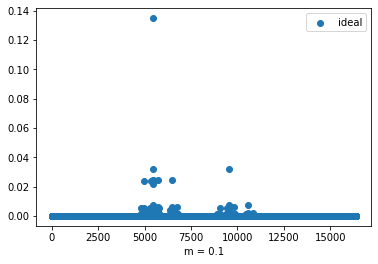

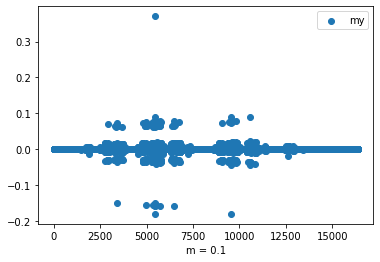

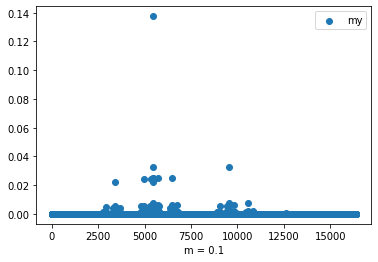

In [12]:
R = my_way.reshape(-1)

# distr = torch.zeros(2**number_of_qubits)
# ind = torch.arange(2**(number_of_qubits - 2))
# distr[ind + 2**(number_of_qubits - 2)] = -R[ind]*0.87
# distr[ind + 2**(number_of_qubits - 1)] = R[ind]*0.44

R = my_way.reshape(-1)
#RR= my_way_8.reshape(-1)
distr = torch.zeros(2**number_of_qubits)
ind = torch.arange(2**(number_of_qubits - 2))
#ind1 = torch.arange(2**(number_of_qubits - 3))
ind2 = torch.arange(2**(number_of_qubits - 4))
distr[ind2 + 2**(number_of_qubits - 2)] = -R[ind2]*0.896

distr[ind2 + 2**(number_of_qubits - 2) + 2**(number_of_qubits - 4)] = -R[ind2 +  2**(number_of_qubits - 4)]*0.863

distr[ind2 + 2**(number_of_qubits - 2) + 2**(number_of_qubits - 3)] = -R[ind2 +  2**(number_of_qubits - 3)]*0.757

distr[ind + 2**(number_of_qubits - 1)] = R[ind]*0.4213
r = distr[1024:2048]
print(r.norm(), distr.norm())

fig, ax = plt.subplots()
x = torch.arange(2**number_of_qubits)
ax.scatter(x, distr**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

ind = (torch.abs(distr) > 0.001).nonzero()
batch = basis[ind].view(-1, number_of_qubits)

CP_batch = CP_conj(batch)
#number_of_qubits = 16
a = 2**torch.arange(number_of_qubits -1, -1,-1)
CP_ind = CP_batch*a 
CP_ind = (CP_ind.sum(dim = 1)).view(CP_ind.shape[0], 1)

#print(((basis[CP_ind.reshape(-1).numpy()].sum(1))), 'good')
distr[CP_ind.numpy()] = distr[ind]
distr = distr/distr.norm()
fig, ax = plt.subplots()

x = torch.arange(2**number_of_qubits)
ax.scatter(x, distr, alpha = 1, label='my')
#ax.scatter(x, my_way_12, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

fig, ax = plt.subplots()

#x = torch.arange(2**16)
ax.scatter(x, distr**2, alpha = 1, label='my')
#ax.scatter(x, my_way_12**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
#print(my_way_12.view(-1).dot(distr))


In [13]:
number_of_qubits = 16
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)


sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch




tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])
8
torch.Size([12870]) torch.Size([12870])


In [14]:
my_way = distr

torch.Size([65536, 1])


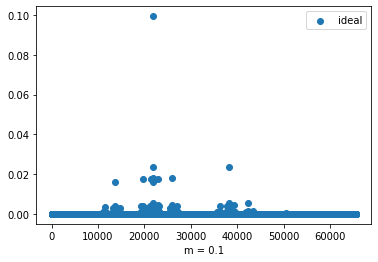

In [15]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_16 (2).npy')).float()

my_way_16 = torch.zeros(2**16, dtype = torch.double)

my_way_16 = torch.zeros(2**16, 1)
i = torch.arange(math.ceil(good_vectors.shape[0]))
my_way_16[good_vectors, 0] = eigenvectors[i, 0]

print(my_way_16.shape)
x = torch.arange(2**16)
fig, ax = plt.subplots()
ax.scatter(x, my_way_16**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

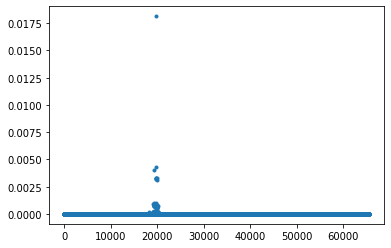

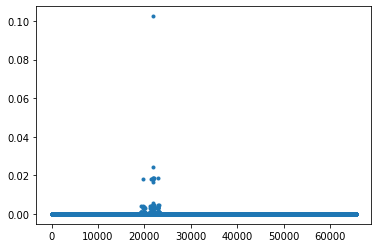

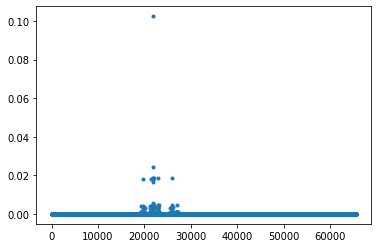

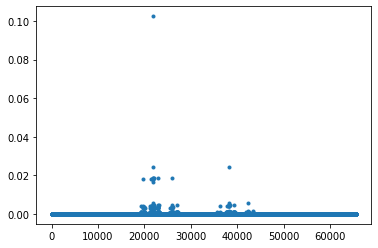

tensor(0.) tensor(0.9465)


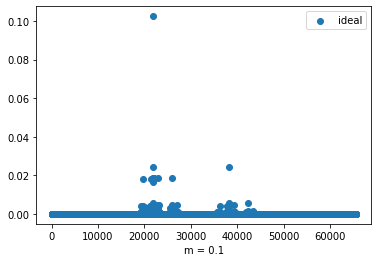

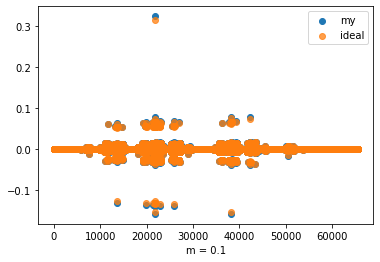

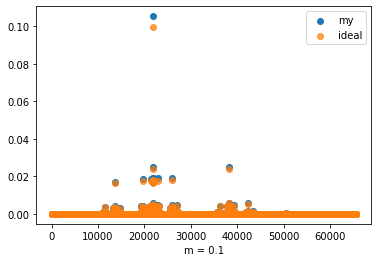

tensor(0.9673)


In [18]:
R = my_way.reshape(-1)

# distr = torch.zeros(2**number_of_qubits)
# ind = torch.arange(2**(number_of_qubits - 2))
# distr[ind + 2**(number_of_qubits - 2)] = R[ind]*0.87
# distr[ind + 2**(number_of_qubits - 1)] = -R[ind]*0.44

R = my_way.reshape(-1)
#RR= my_way_8.reshape(-1)
distr = torch.zeros(2**number_of_qubits)
ind = torch.arange(2**(number_of_qubits - 2))
#ind1 = torch.arange(2**(number_of_qubits - 3))
ind2 = torch.arange(2**(number_of_qubits - 4))
distr[ind2 + 2**(number_of_qubits - 2)] = R[ind2]*0.899
plt.plot(distr**2,'.')
plt.show()

distr[ind2 + 2**(number_of_qubits - 2) + 2**(number_of_qubits - 4)] = R[ind2 +  2**(number_of_qubits - 4)]*0.863
plt.plot(distr**2,'.')
plt.show()

distr[ind2 + 2**(number_of_qubits - 2) + 2**(number_of_qubits - 3)] = R[ind2 +  2**(number_of_qubits - 3)]*0.757
plt.plot(distr**2,'.')
plt.show()

distr[ind + 2**(number_of_qubits - 1)] = -R[ind]*0.4213
plt.plot(distr**2,'.')
plt.show()

r = distr[1024:2048]
print(r.norm(), distr.norm())

fig, ax = plt.subplots()
x = torch.arange(2**number_of_qubits)
ax.scatter(x, distr**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

ind = (torch.abs(distr) > 0.001).nonzero()
batch = basis[ind].view(-1, number_of_qubits)

CP_batch = CP_conj(batch)
#number_of_qubits = 16
a = 2**torch.arange(number_of_qubits -1, -1,-1)
CP_ind = CP_batch*a 
CP_ind = (CP_ind.sum(dim = 1)).view(CP_ind.shape[0], 1)

#print(((basis[CP_ind.reshape(-1).numpy()].sum(1))), 'good')
distr[CP_ind.numpy()] = distr[ind]
distr = distr/distr.norm()
fig, ax = plt.subplots()

x = torch.arange(2**number_of_qubits)
ax.scatter(x, distr, alpha = 1, label='my')
ax.scatter(x, my_way_16, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

fig, ax = plt.subplots()

#x = torch.arange(2**16)
ax.scatter(x, distr**2, alpha = 1, label='my')
ax.scatter(x, my_way_16**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
print(my_way_16.view(-1).dot(distr))
